# ARIMA'yı Ayrıştırma ile Birleştirmek

Basit bir ARIMA modeli sürecini zaten ele almıştık. Bu alıştırmada, derste gördüğünüz `seasonal decompose` aracıyla bir ARIMA modelinin kombinasyonunu kullanarak bu konuyu biraz daha geliştireceğiz. Mevsimsellikle __özel olarak__ başa çıkmak için kullanabileceğimiz modeller var, ancak burada adım adım ilerleyerek bu zaman serisini manuel olarak parçalayacağız, böylece onu tam olarak anlayacağız ve TS verileriyle çalışırken karşılaşabileceğimiz sorunları öğreneceğiz.

Bu challenge için günlük CO2 ppm ölçümleriyle çalışacağız, özellikle Mauna Loa Gözlemevi'nden alınan günlük CO2 ölçümleriyle 🌋

Bu ölçümler 1958'den beri alınıyor ve iklim biliminin temel taşlarından biri. Hawaii'de 3.000 metreden fazla yükseklikte konumlanmış olan gözlemevi, yerel emisyonlardan büyük ölçüde uzak olarak küresel atmosferik karbon seviyelerini izlemek için ideal bir konumdadır. Kayıtlar sağlam olmasına rağmen, __ara sıra enstrüman sorunları veya aşırı hava koşulları nedeniyle boşluklar içermektedir__, araştırmacılar bu kritik veri setinin bütünlüğünü korumak için analizlerinde bunları hesaba katmalıdır. 1974'ten beri __neredeyse__ günlük olarak alınan verilerin bir kısmını kullanacağız - notebook boyunca verilerdeki boşlukları ele alacağız!

Laboratuvarın yaptığı iklim çalışmaları hakkında merak ediyorsanız, buradan daha fazla bilgi edinebilirsiniz: https://gml.noaa.gov/ccgg/about/co2_measurements.html

## Veriyi Yükleme ve Keşfetme

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv("https://d32aokrjazspmn.cloudfront.net/materials/co2_daily_mlo.csv")

In [3]:
df

,year,month,day,CO2 molfrac (ppm)
0,1974,5,17,333.38
1,1974,5,18,333.11
2,1974,5,19,333.46
3,1974,5,20,333.64
4,1974,5,21,333.50
...,...,...,...,...
15191,2023,10,19,419.44
15192,2023,10,20,419.53
15193,2023,10,21,418.90
15194,2023,10,23,419.09


Verilerin çalışmamız için pek güzel formatlanmadığını görebiliyoruz, bu yüzden önce `pd.to_datetime()` kullanarak bu adımı çözelim (bu fonksiyonu aynı anda birden fazla sütunda kullanabilirsiniz 👀). Daha fazla bilgi için [dokümanları](https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html) kontrol edin.

Doğru şekilde formatladıktan sonra, bunu index olarak ayarlayın.

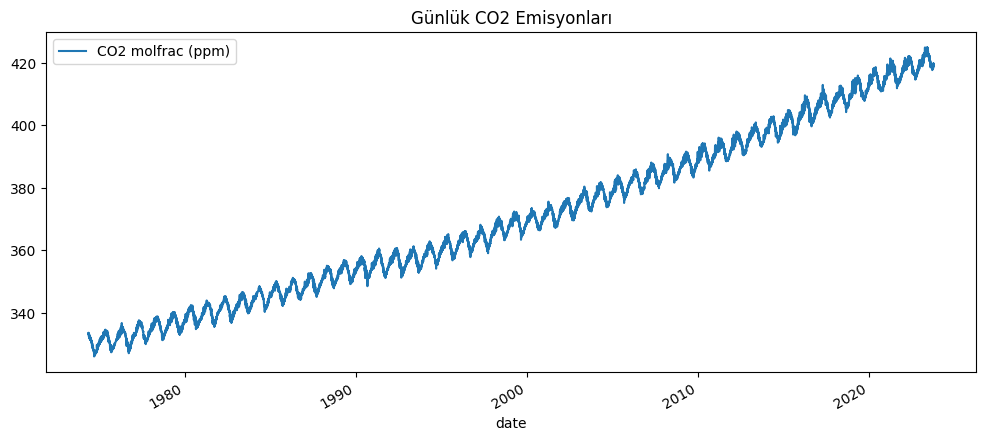

In [5]:
# Yıl, ay, gün sütunlarını tek bir datetime nesnesine birleştiriyoruz
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

# Bunu index yapıyoruz ve gereksiz sütunları atıyoruz
df = df.set_index('date')
df = df.drop(columns=['year', 'month', 'day'])

# Veriyi çizdir
df.plot(figsize=(12, 5))
plt.title("Günlük CO2 Emisyonları")
plt.show()

CO2 değerlerinizi çizdirin ve partnerinizle ne gördüğünüzü tartışın. Verilerinizde herhangi bir boşluk var gibi görünüyor mu? __Emin misiniz__? DataFrame'inizin ilk 50 değerini kontrol edin

In [6]:
df.head(50)

,CO2 molfrac (ppm)
date,
1974-05-17,333.38
1974-05-18,333.11
1974-05-19,333.46
1974-05-20,333.64
1974-05-21,333.50
1974-05-22,333.21
1974-05-23,333.05
1974-05-26,333.32
1974-05-27,332.79


Bazı tarihleri kaybetmişiz 😱 Açık `NaN` değerlerimiz olmasa da, index'imizde eksik tarihler var. Bu, TS verileriyle çalışırken __gerçekten__ dikkatli olmanız gereken bir şey.

Kaç gün eksik olduğumuzu hesaplayalım. Bitiş tarihinizi (`index`'inizin `max()`'ı) başlangıç tarihinizden (`index`'inizin `min()`'ı) çıkararak ikisi arasında kaç gün __olması gerektiğini__ görelim.

In [10]:
# Sadece iki tarih arasındaki matematiksel farkı alıyoruz (+1 yok)
total_expected_days = (df.index.max() - df.index.min()).days

# Elimizdeki gerçek satır sayısı
actual_days = len(df)

# Eksik günleri değişkene kaydet
missing = total_expected_days - actual_days
print(f"Eksik gün sayısı: {missing}")

Eksik gün sayısı: 2861


Bu, DataFrame'imizde __gerçekten__ sahip olduğumuz gün sayısından nasıl farklı? Cevabınızı `missing` değişkenine kaydedin

In [11]:
# Eksiksiz bir tarih aralığı oluştur
full_date_range = pd.date_range(start=df.index.min(), end=df.index.max())

# Veriyi bu aralığa oturt
df_reindexed = df.reindex(full_date_range)

# İçinde null olan ilk 100 kaydı göster
df_reindexed.head(100)[df_reindexed.head(100).isnull().any(axis=1)]

,CO2 molfrac (ppm)
1974-05-24,NaN
1974-05-25,NaN
1974-06-01,NaN
1974-06-02,NaN
1974-06-03,NaN
1974-06-26,NaN
1974-06-29,NaN
1974-07-01,NaN
1974-07-07,NaN
1974-07-14,NaN


In [12]:
from nbresult import ChallengeResult

result = ChallengeResult('missing',
                         missing = missing)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/cem/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/cem/code/gcemozdogan/S17D4-S-arima-seasonal/tests
plugins: typeguard-4.4.2, dash-4.0.0, anyio-4.8.0
collecting ... collected 1 item

test_missing.py::TestMissing::test_missing PASSED                        [100%]

============================== 1 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/missing.pickle

git commit -m 'Completed missing step'

git push origin master



Eksik değerlerin gerçekte nerede olduğunu görelim. Sahip __olmamız gereken__ index'i oluşturmak için `pd.date_range` kullanın. Ardından DataFrame'in `.reindex()` fonksiyonunu bu yeni tarih aralığıyla kullanarak ilk 100 girişimizde null değerlerin gerçekte nerede olduğunu görün!

In [13]:
# Tüm günleri içeren index'i oluştur ve reindex yap
full_date_range = pd.date_range(start=df.index.min(), end=df.index.max())
df_reindexed = df.reindex(full_date_range)

# İlk 100 kayıttaki eksik değerleri göster
df_reindexed.head(100)[df_reindexed.head(100).isnull().any(axis=1)]

,CO2 molfrac (ppm)
1974-05-24,NaN
1974-05-25,NaN
1974-06-01,NaN
1974-06-02,NaN
1974-06-03,NaN
1974-06-26,NaN
1974-06-29,NaN
1974-07-01,NaN
1974-07-07,NaN
1974-07-14,NaN


Buradaki en basit seçenek, çok kullanışlı olan `pd.interpolate("linear")` fonksiyonunu kullanarak bunları bizim için doldurmak. Ne yaptığını görmek için aşağıdaki hücreyi çalıştırmayı deneyin:

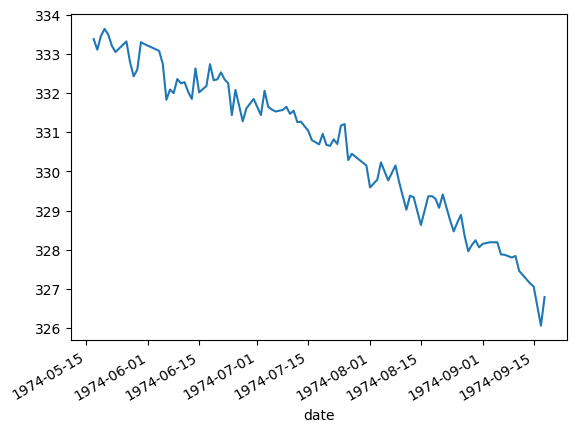

In [14]:
df["CO2 molfrac (ppm)"][:100].interpolate("linear").plot();

Interpolation bizim için noktaları bağlamak için basit bir doğrusal yöntem kullanır 😊 Tabii ki bu mükemmel olmayan bazı varsayımlar yapıyor ve aslında günlük örneklere ihtiyacımız yok - bunun yerine DataFrame'imizi aylık bazda `resample` edeceğiz ve bunu modellemeye çalışacağız. Her ayın ortalamasını içeren bir DataFrame oluşturmak için `.resample()` fonksiyonunu kullanmayı deneyin ve bunu `monthly` olarak adlandırın. [Dokümanları](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.resample.html) burada görün.

In [15]:
# Veriyi aylık ortalamalara çevir (MS = Month Start)
monthly = df_reindexed.resample('MS').mean()

Eğer __hala__ kalan null değerleriniz varsa, bunları doldurmak için `interpolate` kullanabilirsiniz. Yeniden örneklenmiş verilerinizi çizdirin:

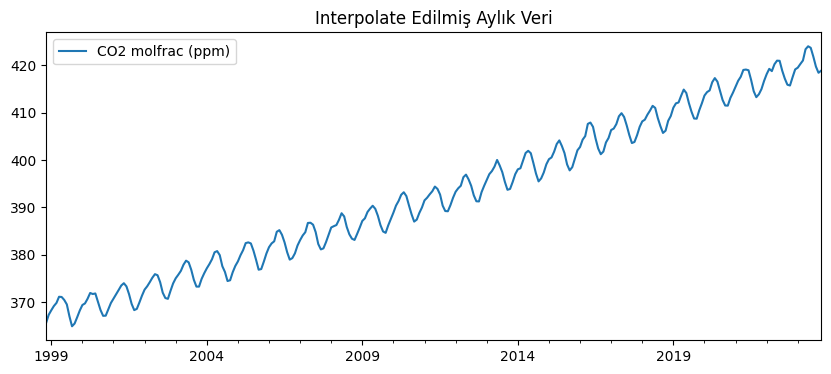

In [16]:
# Kalan null değerleri lineer olarak doldur
monthly = monthly.interpolate(method='linear')

# Çizdir
monthly[-300:].plot(figsize=(10, 4), title="Interpolate Edilmiş Aylık Veri")
plt.show()

<Axes: >

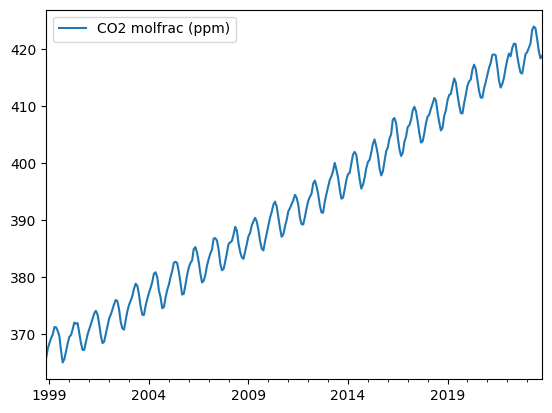

In [17]:
monthly[-300:].plot()

In [18]:
monthly["CO2 molfrac (ppm)"].iloc[0]

333.1569230769231

In [19]:
from nbresult import ChallengeResult

result = ChallengeResult('monthly',
                         monthly = monthly)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/cem/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/cem/code/gcemozdogan/S17D4-S-arima-seasonal/tests
plugins: typeguard-4.4.2, dash-4.0.0, anyio-4.8.0
collecting ... collected 2 items

test_monthly.py::TestMonthly::test_first_value PASSED                    [ 50%]
test_monthly.py::TestMonthly::test_missing PASSED                        [100%]

============================== 2 passed in 0.91s ===============================


💯 You can commit your code:

git add tests/monthly.pickle

git commit -m 'Completed monthly step'

git push origin master



## Eğitim Test Ayrımı

Şimdi eğitim ve test kümelerine ayırmamız gerekiyor (%80:%20 ayrımı yapacağız). Bunu yaparken dikkatli olun - kümelerimizin __sürekli__ olması gerekiyor!

In [20]:
# %80 Train, %20 Test
split_idx = int(len(monthly) * 0.8)
train = monthly.iloc[:split_idx].copy()
test = monthly.iloc[split_idx:].copy()

Veri hazırlığımız neredeyse bitti. Ancak ayrıştırma ve modellemeye başlamadan önce, modelimizin nasıl performans gösterdiğini görmek için bir baseline oluşturmalıyız.

Seçeceğimiz tipik baseline, bize mevcut olan son değeri tahmin etmektir. Bizim durumumuzda, bu sadece `train` DataFrame'imizdeki son noktadır.

`test` DataFrame'inizde `naive_preds` adında bir sütun oluşturun ve bunu `train`'deki son mevcut veri noktamıza eşit olarak ayarlayın


In [21]:
# Train'deki son değeri naive tahmin olarak ata
test['naive_preds'] = train["CO2 molfrac (ppm)"].iloc[-1]

Bunu yaptıktan sonra, iki sütun arasındaki ortalama mutlak hatayı hesaplayın ve bunu `baseline_mae` olarak ayarlayın.

In [22]:
from sklearn.metrics import mean_absolute_error

# Baseline hatasını hesapla
baseline_mae = mean_absolute_error(test["CO2 molfrac (ppm)"], test['naive_preds'])
print(f"Baseline MAE: {baseline_mae}")

Baseline MAE: 14.503777783267303


In [23]:
from nbresult import ChallengeResult

result = ChallengeResult('baseline',
                         test = test,
                         baseline_mae = baseline_mae)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/cem/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/cem/code/gcemozdogan/S17D4-S-arima-seasonal/tests
plugins: typeguard-4.4.2, dash-4.0.0, anyio-4.8.0
collecting ... collected 3 items

test_baseline.py::TestBaseline::test_baseline_mae PASSED                 [ 33%]
test_baseline.py::TestBaseline::test_first_value PASSED                  [ 66%]
test_baseline.py::TestBaseline::test_missing PASSED                      [100%]

=============================== warnings summary ===============================
test_baseline.py::TestBaseline::test_first_value
  /home/cem/code/gcemozdogan/S17D4-S-arima-seasonal/tests/test_baseline.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame beh

## Modellemeye Hazırlanmak

Bazı Zaman Serisi modelleriyle, verilerimizi modele atabilir ve onun bizim için ayrıştırmasını, durağan hale getirmesini ve sonra modellemesini umabiliriz (SARIMAX veya TBATS bunun iyi örnekleridir), ancak bunun yerine adım adım ilerleyeceğiz. Mevsimsellik ve trendi bizim için kaldıracak bir modele güvenmediğimiz için, bunları kendimiz halledeceğiz.

Derste gördüğünüz `seasonal_decompose` aracını import edin ve Zaman Serinizde her iki yöntemi de deneyin (hem "multiplicative" hem "additive").

In [24]:
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Multiplicative (Çarpımsal) ayrıştırma
decompose_mult = seasonal_decompose(train["CO2 molfrac (ppm)"], model='multiplicative')

# 2. Additive (Toplamsal) ayrıştırma
decompose_add = seasonal_decompose(train["CO2 molfrac (ppm)"], model='additive')

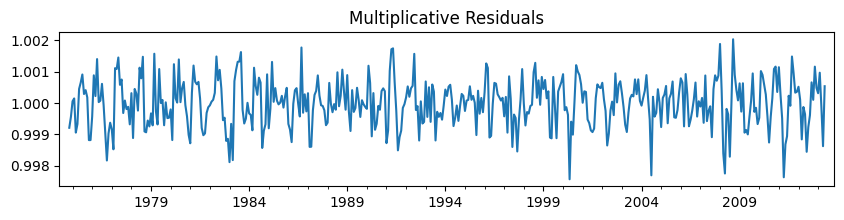

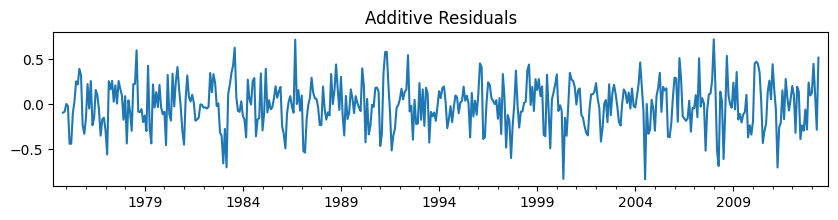

In [25]:
# Multiplicative artıkları
decompose_mult.resid.plot(title="Multiplicative Residuals", figsize=(10, 2))
plt.show()

# Additive artıkları
decompose_add.resid.plot(title="Additive Residuals", figsize=(10, 2))
plt.show()

In [26]:
# Train'e mevsimsellik sütununu ekle
train['seasonal_component'] = decompose_mult.seasonal

# Sadece ilk 12 ayı al
seasonal_one_year = train[['seasonal_component']].iloc[:12].copy()

# Ay bilgisi sütunu ekle
seasonal_one_year['month'] = seasonal_one_year.index.month

Her ikisinden de residualleri (`.resid` attribute'una erişin) çizdirin ve unutmayın - zamandan mümkün olduğunce __etkilenmemiş__ görünen olanı istiyoruz

In [27]:
# Çarpımsal olduğu için bölerek mevsimselliği çıkar
train['seasonal_stripped'] = train["CO2 molfrac (ppm)"] / train['seasonal_component']

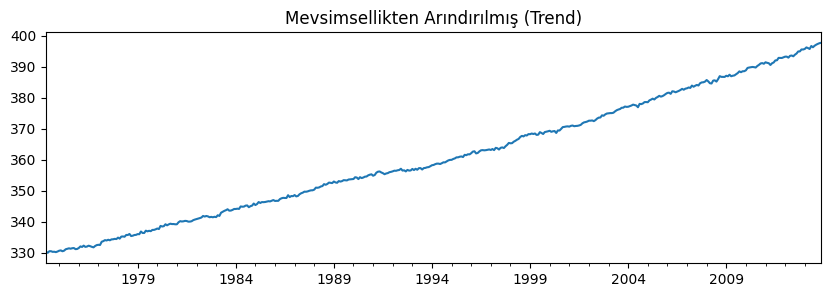

In [28]:
train['seasonal_stripped'].plot(title="Mevsimsellikten Arındırılmış (Trend)", figsize=(10, 3))
plt.show()

Her ikisi de makul ölçüde durağan göründüğü için, multiplicative modeli seçeceğiz.

Şimdi stratejimiz zaman serimizin mevsimsel bileşenini çıkarmak.

Bunu nasıl yapabiliriz? 🤔


İlk olarak, `train` DataFrame'inizde zaman serinizin `.seasonal` bileşeniyle doldurulmuş `"seasonal_component"` adında bir sütun oluşturun.

Bunu yaptıktan sonra, sadece mevsimsel bileşenlerinizin __bir yılını__ içeren (yani `seasonal components` sütununuzun ilk 12 satırı) ayrı, daha küçük bir DataFrame oluşturun. Bu daha sonra bizim için yararlı olacak. Bunu `seasonal_one_year` olarak adlandırın ve karşılık gelen `index.month`'a eşit bir `"month"` sütununuz olduğundan emin olun (örneğin, Ocak mevsimsel bileşenine sahip bir satırınız ve yanında 1 olsun).

<img src = "https://wagon-public-datasets.s3.amazonaws.com/data-science-images/05-ML/09-Time-Series/seasonal_component_one.png">

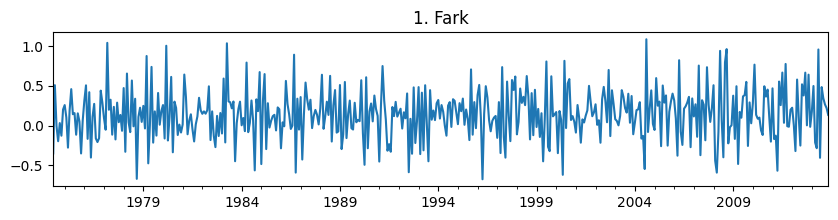

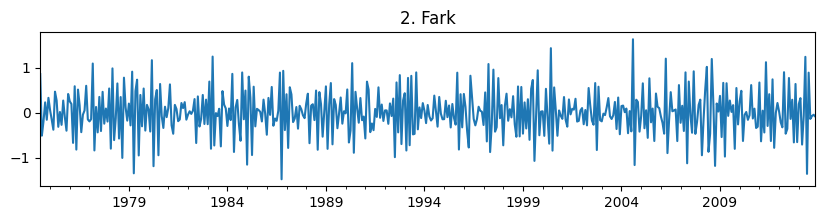

In [29]:
# 1. ve 2. farkları al
diff_1 = train['seasonal_stripped'].diff().dropna()
diff_2 = diff_1.diff().dropna()

diff_1.plot(title="1. Fark", figsize=(10, 2)); plt.show()
diff_2.plot(title="2. Fark", figsize=(10, 2)); plt.show()

Bu multiplicative bir modelden geldiği için, bu mevsimsel bileşeni __kaldırmak__ istiyorsak, orijinal zaman serimizi bu tekrarlanan (12 aylık döngü) değerlere __bölmemiz__ gerekecek.

In [30]:
from nbresult import ChallengeResult

result = ChallengeResult('seasonal',
                         train = train,
                         seasonal = seasonal_one_year)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/cem/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/cem/code/gcemozdogan/S17D4-S-arima-seasonal/tests
plugins: typeguard-4.4.2, dash-4.0.0, anyio-4.8.0
collecting ... collected 2 items

test_seasonal.py::TestSeasonal::test_seasonal_column PASSED              [ 50%]
test_seasonal.py::TestSeasonal::test_seasonal_year_shape PASSED          [100%]

============================== 2 passed in 0.44s ===============================


💯 You can commit your code:

git add tests/seasonal.pickle

git commit -m 'Completed seasonal step'

git push origin master



Orijinal zaman serinizin değerini mevsimsel bileşene bölen `"seasonal_stripped"` adında yeni bir sütun oluşturun.

In [38]:
train["seasonal_stripped"] = train["CO2 molfrac (ppm)"] / train["seasonal_component"]

Bu yeni sütunu çizdirin:

Henuz durağan görünüyor mu? Günün arkadaşınızla neden öyle olduğunu veya olmadığını tartışın.

Bir sonraki görevimiz bu __mevsimsellikten arındırılmış__ zaman serisini alıp durağan hale getirmek. `.diff()` kullanmayı deneyin ve nasıl göründüğüne bakın. Sonra herhangi bir değişiklik görmek için bir kez daha diff yapmayı deneyin.

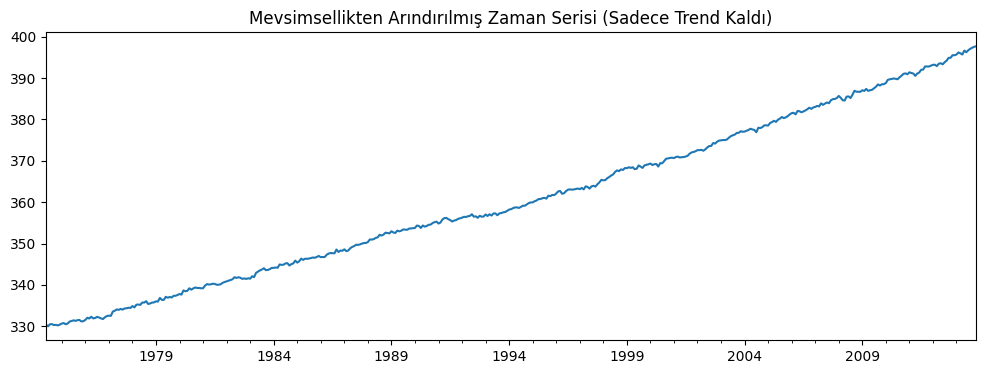

In [39]:
train["seasonal_stripped"].plot(figsize=(12, 4), title="Mevsimsellikten Arındırılmış Zaman Serisi (Sadece Trend Kaldı)")
plt.show()

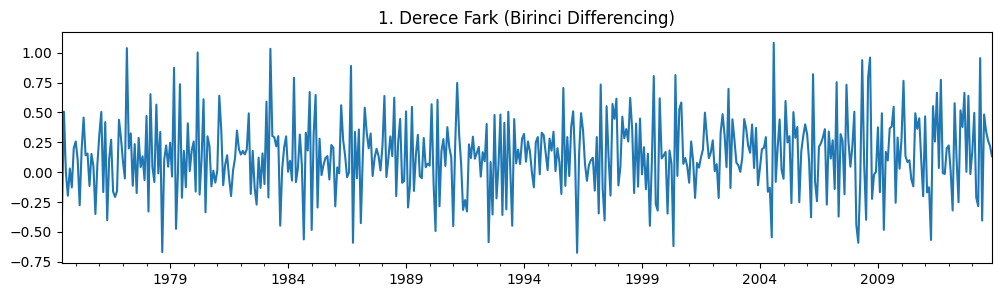

In [40]:
# Bir adım geriye gidip fark alıyoruz ve baştaki NaN değeri siliyoruz
diff_1 = train["seasonal_stripped"].diff().dropna()
diff_1.plot(figsize=(12, 3), title="1. Derece Fark (Birinci Differencing)")
plt.show()

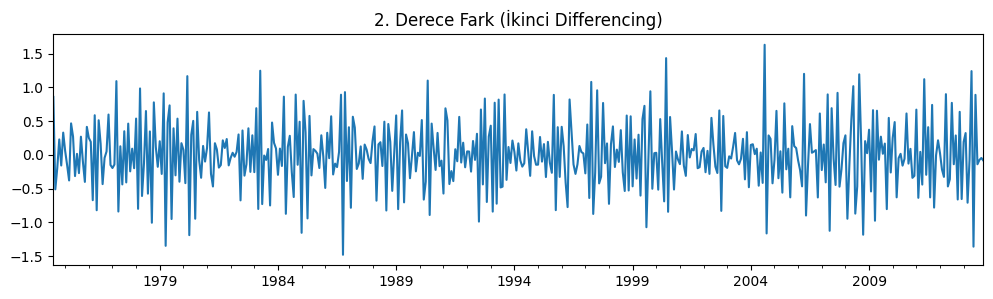

In [41]:
# Emin olmak için birinci farkın üzerinden bir daha fark alıyoruz
diff_2 = diff_1.diff().dropna()
diff_2.plot(figsize=(12, 3), title="2. Derece Fark (İkinci Differencing)")
plt.show()

Her ikisi de görsel olarak oldukça durağan görünmeli, her birinin durağan olduğunu doğrulamak için derste gördüğünüz `adfuller` (Augmented Dicky-Fuller) testini kullanın.

Not: `diff` yaptığınızda DataFrame'inizde null değerler oluşturursunuz, ADF testi yapmak için bunları düşürmeniz gerekir.

In [42]:
from statsmodels.tsa.stattools import adfuller

In [43]:
adf_1 = adfuller(diff_1)
print(f"1. Derece Fark p-değeri: {adf_1[1]}")

1. Derece Fark p-değeri: 4.816418008793031e-06


In [44]:
adf_2 = adfuller(diff_2)
print(f"2. Derece Fark p-değeri: {adf_2[1]}")

2. Derece Fark p-değeri: 1.2453738770613722e-23


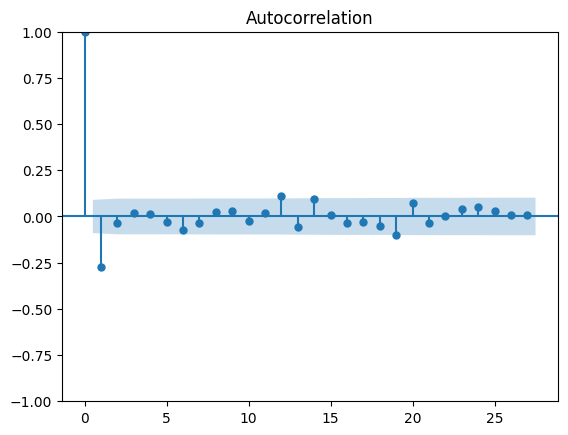

In [45]:
plot_acf(diff_1)
plt.show()

In [46]:
best_AIC = auto_model.aic()

Her ikisi de makul ölçüde durağan görünüyor ve aşırı differencing'e gerek yok gibi görünüyor (yine de daha sonra iki kez diff yapılmış bir zaman serisi oluşturmayı her zaman deneyebiliriz). Hadi `acf` ve `pacf` grafiklerimizi çizmeye devam edelim (herhangi bir `null` değeri düşürdüğünüzden emin olun - bunlar ACF ve PACF hesaplayıcılarınızı bozar) 😔

In [47]:
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf

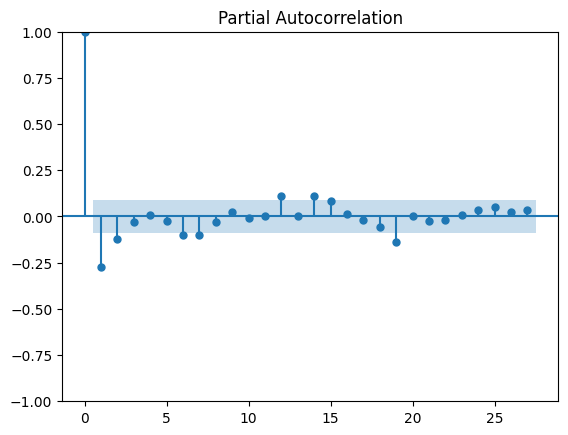

In [48]:
plot_pacf(diff_1)
plt.show()

Bu grafiklerin gerçekte ne anlama geldiğini arkadaşınızla konuşmak için zaman ayırın. Hangisi sizin `p` parametrenize karşılık geliyor ve hangisi `q` parametrenize?

Şimdi `p` `d` ve `q` değerleriniz için uygun order değerleriyle basit bir ARIMA modeli oluşturun. Model özetini inceleyin.

Özet hakkında ne fark ediyorsunuz? Buradaki en önemli özellikler neler?

Katsayılarımıza güvenebiliriz gibi görünüyor ve ~223'lük bir AIC'miz var. Ama bu en iyi model miydi? Farklı modelleri grid search yapmak ve hangisinin en iyi AIC'ye sahip olduğunu görmek için `auto_arima` fonksiyonunu kullanmayı deneyin

In [49]:
train

,CO2 molfrac (ppm),seasonal_component,seasonal_stripped
1974-05-01,333.156923,1.008482,330.354959
1974-06-01,332.170400,1.006564,330.004173
1974-07-01,331.110000,1.001811,330.511417
1974-08-01,329.105769,0.995762,330.506354
1974-09-01,327.303182,0.990900,330.308904
...,...,...,...
2013-07-01,397.451905,1.001811,396.733388
2013-08-01,395.393704,0.995762,397.076392
2013-09-01,393.726538,0.990900,397.342246
2013-10-01,393.904286,0.990801,397.561262


In [50]:
from statsmodels.tsa.arima.model import ARIMA

# p=1, d=1, q=1 değerleriyle basit bir model kuralım
model = ARIMA(train["seasonal_stripped"], order=(1, 1, 1))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:      seasonal_stripped   No. Observations:                  475
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -126.839
Date:                Fri, 13 Mar 2026   AIC                            259.678
Time:                        19:19:33   BIC                            272.162
Sample:                    05-01-1974   HQIC                           264.588
                         - 11-01-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9999      0.000   2716.060      0.000       0.999       1.001
ma.L1         -0.9952      0.011    -86.573      0.000      -1.018      -0.973
sigma2         0.0993      0.006     16.010      0.0

In [51]:
import pmdarima as pm

In [52]:
auto_model = pm.auto_arima(
    train["seasonal_stripped"],
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    d=1, # 1. farkın yettiğini gördüğümüz için d=1 veriyoruz
    trace=True,
    suppress_warnings=True
)

print(auto_model.summary())

/home/cem/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/cem/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/cem/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/cem/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/cem/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=252.307, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=216.874, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=209.862, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=338.365, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=211.246, Time=0.07 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=211.280, Time=0.06 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=213.283, Time=0.15 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=339.127, Time=0.02 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0] intercept
Total fit time: 0.443 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  475
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -101.931
Date:                Fri, 13 Mar 2026   AIC                            209.862
Time:                        19:19:58   BIC 

/home/cem/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/cem/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


En iyi AIC skorunuzu `best_AIC`'ye kaydedin

In [53]:
best_AIC = auto_model.aic()
print(f"En İyi AIC Skoru: {best_AIC}")

En İyi AIC Skoru: 209.8617681053015


In [54]:
from nbresult import ChallengeResult

result = ChallengeResult('score',
                         aic_score = best_AIC)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/cem/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/cem/code/gcemozdogan/S17D4-S-arima-seasonal/tests
plugins: typeguard-4.4.2, dash-4.0.0, anyio-4.8.0
collecting ... collected 1 item

test_score.py::TestScore::test_AIC_score PASSED                          [100%]

============================== 1 passed in 0.19s ===============================


💯 You can commit your code:

git add tests/score.pickle

git commit -m 'Completed score step'

git push origin master



Çoğu zaman, hangi modelin verilerimize en iyi uyacağını tahmin etmek zor olabilir, bu yüzden genellikle grid-search yapmak ve modellerimizin AIC skorlarını karşılaştırmak iyi bir fikirdir 🧐 Burada, bir __(0,1,1)__ modelinin daha iyi bir AIC skoru aldığı görünüyor (yani orijinal modelimizin MA bileşenleri muhtemelen model likelihood'ımızı o kadar iyileştirmiyordu!)

### Tahminler Yapmak (biraz Pandas çalışmasına hazır olun!)

Artik en iyi modelimize sahip olduğumuza göre, bazı tahminler ve - önemlisi - bazı güven aralıkları oluşturmak istiyoruz. Test setinizin uzunluğu için tahmin yapmak üzere modelinizi kullanın ve bu aralıkları da döndürdüğünüzden emin olun (`return_conf_int = True` kullanın). `preds`, `upper` ve `lower` sınırları için sütunlar içeren bir `preds_df` DataFrame oluşturun.

In [55]:
# Test setimizin uzunluğu kadar tahmin yapıyoruz ve güven aralıklarını istiyoruz
forecast, conf_int = auto_model.predict(n_periods=len(test), return_conf_int=True)

# Çıktıları bir DataFrame içinde topluyoruz
preds_df = pd.DataFrame({
    'preds': forecast,
    'upper': conf_int[:, 1],
    'lower': conf_int[:, 0]
})

/home/cem/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/cem/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [56]:
from nbresult import ChallengeResult

result = ChallengeResult('preds',
                         preds_df = preds_df)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/cem/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/cem/code/gcemozdogan/S17D4-S-arima-seasonal/tests
plugins: typeguard-4.4.2, dash-4.0.0, anyio-4.8.0
collecting ... collected 2 items

test_preds.py::TestPreds::test_df_values PASSED                          [ 50%]
test_preds.py::TestPreds::test_preds_cols PASSED                         [100%]

============================== 2 passed in 0.69s ===============================


💯 You can commit your code:

git add tests/preds.pickle

git commit -m 'Completed preds step'

git push origin master



Şimdi bunları çizdirin ve `train` verilerinizle karşılaştırıldığında nasıl göründüklerine bakın

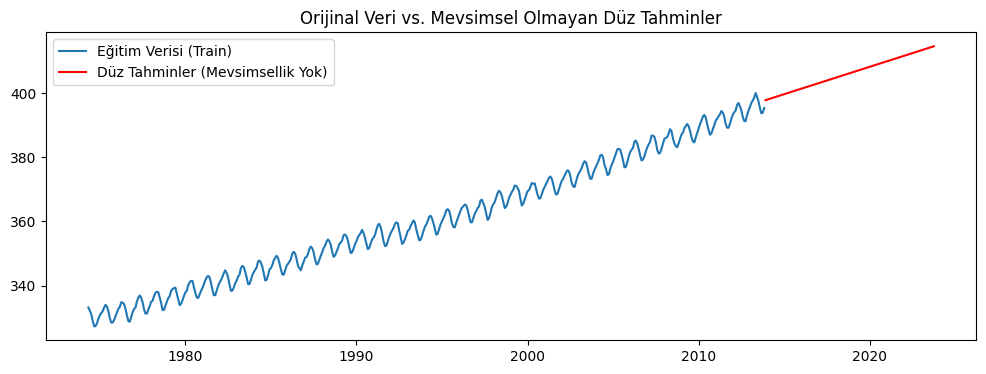

In [57]:
plt.figure(figsize=(12, 4))
plt.plot(train.index, train["CO2 molfrac (ppm)"], label="Eğitim Verisi (Train)")
# Çizim için test indexini kullanıyoruz
plt.plot(test.index, preds_df['preds'], label="Düz Tahminler (Mevsimsellik Yok)", color="red")
plt.title("Orijinal Veri vs. Mevsimsel Olmayan Düz Tahminler")
plt.legend()
plt.show()

Bir şeyler biraz yanlış görünüyor, değil mi? Açıkça mevsimsellik olan bir şeyden çıkan üç düz çizgiye bakıyoruz. Bunu hesaba katmak için, daha önce çıkardığımız mevsimsellik bileşenini yeniden dahil etmemiz gerekiyor!

`preds_df` DataFrame'inizde bir `month` sütunu oluşturun ve bunu index'in ay bileşeniyle doldurun.

In [58]:
# Merge işlemi için test setindeki ayları alıp preds_df'e ekliyoruz
preds_df['month'] = test.index.month

Artık daha önce oluşturduğumuz `seasonal_one_year` DataFrame'ini alıp `preds_df`'imize basitçe merge edebiliriz!

In [60]:
# Orijinal katsayılarımızı aylara göre eşleştirerek tahmin tablomuza katıyoruz
preds_df = preds_df.merge(seasonal_one_year, on='month', how='left')

In [61]:
preds_df

,preds,upper,lower,month,seasonal_component_x,seasonal_component_y
0,397.824555,398.412512,397.236599,12,0.997567,0.997567
1,397.966868,398.676377,397.257358,1,1.000244,1.000244
2,398.109180,398.922270,397.296090,2,1.002097,1.002097
3,398.251492,399.156383,397.346602,3,1.004264,1.004264
4,398.393805,399.382004,397.405605,4,1.007375,1.007375
...,...,...,...,...,...,...
114,414.048167,418.328912,409.767421,6,1.006564,1.006564
115,414.190479,418.489606,409.891352,7,1.001811,1.001811
116,414.332791,418.650221,410.015361,8,0.995762,0.995762
117,414.475104,418.810760,410.139448,9,0.990900,0.990900


Şimdi `preds_df` DataFrame'inde yeni sütunlar olarak `full_preds`, `upper_conf` ve `lower_conf`'ı (`preds`, `upper` __ve__ `lower` sütunlarınızı `preds_df` DataFrame'imizde artık sahip olduğumuz mevsimsel bileşenle çarparak) oluşturabilirsiniz.

In [63]:
# 1. Tahminleri ve güven aralıklarını çekip tabloyu baştan kuruyoruz
forecast, conf_int = auto_model.predict(n_periods=len(test), return_conf_int=True)

preds_df = pd.DataFrame({
    'preds': forecast,
    'upper': conf_int[:, 1],
    'lower': conf_int[:, 0]
})

# 2. Ay (month) sütununu ekliyoruz
preds_df['month'] = test.index.month

# 3. İŞTE KRİTİK NOKTA: Birleştirip TEKRAR preds_df üzerine yazıyoruz
preds_df = preds_df.merge(seasonal_one_year, on='month', how='left')

# 4. Artık tablomuzda 'seasonal_component' var, çarpma işlemlerini güvenle yapabiliriz
preds_df['full_preds'] = preds_df['preds'] * preds_df['seasonal_component']
preds_df['upper_conf'] = preds_df['upper'] * preds_df['seasonal_component']
preds_df['lower_conf'] = preds_df['lower'] * preds_df['seasonal_component']

# 5. Çizimlerde sorun olmaması için index'i test setiyle hizalıyoruz
preds_df.index = test.index

# Son durumu kontrol etmek için ilk 5 satıra bakalım
print(preds_df.head())

                 preds       upper       lower  month  seasonal_component  \
2013-12-01  397.824555  398.412512  397.236599     12            0.997567   
2014-01-01  397.966868  398.676377  397.257358      1            1.000244   
2014-02-01  398.109180  398.922270  397.296090      2            1.002097   
2014-03-01  398.251492  399.156383  397.346602      3            1.004264   
2014-04-01  398.393805  399.382004  397.405605      4            1.007375   

            full_preds  upper_conf  lower_conf  
2013-12-01  396.856692  397.443218  396.270166  
2014-01-01  398.064148  398.773831  397.354465  
2014-02-01  398.944099  399.758894  398.129304  
2014-03-01  399.949716  400.858465  399.040967  
2014-04-01  401.331956  402.327444  400.336469  


/home/cem/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/cem/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Son olarak, plotting'i bizim için kolaylaştırmak için, `preds_df`'nizin index'ini `test` DataFrame'inizin index'iyle aynı olacak şekilde ayarlayın (aynı uzunluğa sahip oldukları için bu bizim için oldukça kolay olmalı!)

In [68]:
import pandas as pd

# Index'teki tarihleri ayın başından ayın sonuna kaydırıyoruz
preds_df.index = preds_df.index + pd.offsets.MonthEnd(0)

# Çizimlerde sırıtmasın diye test setinin de indexini kaydıralım
test.index = test.index + pd.offsets.MonthEnd(0)
train.index = train.index + pd.offsets.MonthEnd(0)

In [69]:
from nbresult import ChallengeResult

result = ChallengeResult('fullpreds',
                         preds_df = preds_df)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/cem/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/cem/code/gcemozdogan/S17D4-S-arima-seasonal/tests
plugins: typeguard-4.4.2, dash-4.0.0, anyio-4.8.0
collecting ... collected 2 items

test_fullpreds.py::TestFullpreds::test_columns PASSED                    [ 50%]
test_fullpreds.py::TestFullpreds::test_index PASSED                      [100%]

============================== 2 passed in 0.36s ===============================


💯 You can commit your code:

git add tests/fullpreds.pickle

git commit -m 'Completed fullpreds step'

git push origin master



Şimdi her şeyi çizdirin - train'inizin sonu (örneğin son 100 değer), tam tahminleriniz, üst ve alt güven sınırları ve `preds_df` DataFrame'inizden gerçek değerler __ve__ baseline'nız!

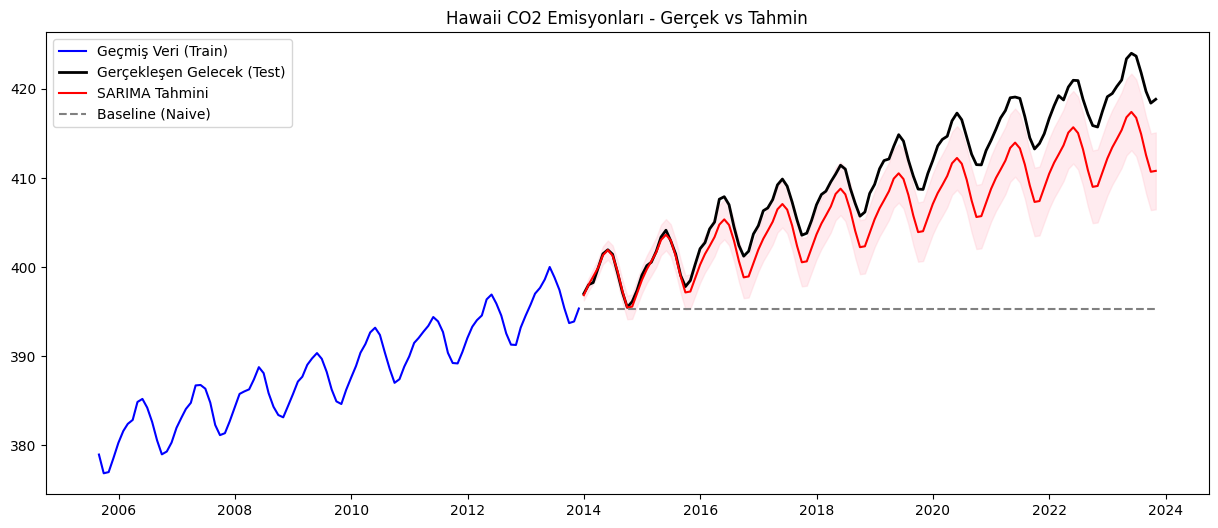

In [70]:
plt.figure(figsize=(15, 6))

# Train'inizin sonu (son 100 değer)
plt.plot(train.index[-100:], train["CO2 molfrac (ppm)"].iloc[-100:], label="Geçmiş Veri (Train)", color="blue")

# Gerçek değerler (Test)
plt.plot(test.index, test["CO2 molfrac (ppm)"], label="Gerçekleşen Gelecek (Test)", color="black", linewidth=2)

# Tam tahminlerimiz (Mevsimsellik eklenmiş)
plt.plot(preds_df.index, preds_df['full_preds'], label="SARIMA Tahmini", color="red")

# Üst ve alt güven sınırları (Pembe bant)
plt.fill_between(preds_df.index, preds_df['lower_conf'], preds_df['upper_conf'], color="pink", alpha=0.3)

# Baseline'ımız
plt.plot(test.index, test['naive_preds'], label="Baseline (Naive)", linestyle="--", color="gray")

plt.title("Hawaii CO2 Emisyonları - Gerçek vs Tahmin")
plt.legend()
plt.show()

Tahminlerimiz oldukça iyi görünüyor! Gerçek değerlerin tahmin ettiklerimizden biraz daha yüksek olduğunu görebiliyoruz ancak tahmin yapmaya başladığımız zamandan tam 10 yıl sonrası için güven aralıklarımızın sınırları içinde iyi bir şekilde kalıyor.

Neden değerlerimiz gerçek değerlerin altına düştü? Test verisini ayrıştırmak ve trend bileşenine bakmak için aşağıdaki hücreyi çalıştırın 👀


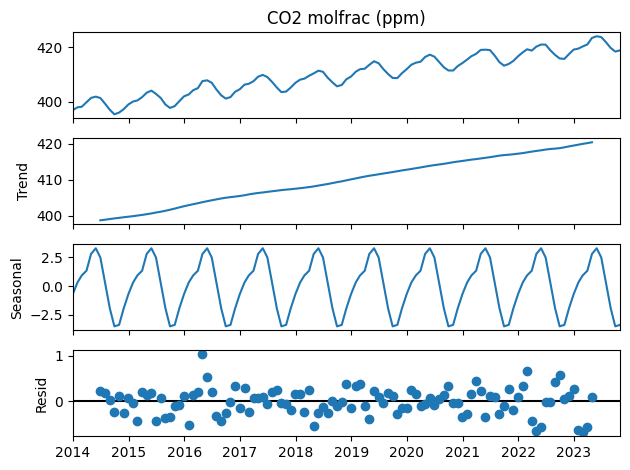

In [71]:
seasonal_decompose(test["CO2 molfrac (ppm)"]).plot();

2016-2018'de normal (biraz daha sığ) trend tekrar devralınmadan önce tüm değerlerimizde __hafif bir artis__ olduğu görünüyor. Bu, test veri setimizde basitçe tahmin edemeyeceğimiz bir şeyin meydana gelmesinin harika bir örneği. CO2 okumalarında neden bir artış olduğunu bilmiyoruz - ve bunun için tahmin yapamadık.

❗ Zaman Serisi ile modelleme yaptığımızda, __sihirli bir şekilde geleceği tahmin edemeyiz__. Yapmaya çalıştığımız şey, geçmişin desenlerini doğru bir şekilde yakalamak ve sonra bunları genişletmektir.

- Çoğu zaman, ham tahminleriniz (mevsimsel bileşen olmadan) oldukça sıkıcı düz bir çizgi gibi görünecektir 🙄 (mevcut başlangıç tahminlerimizin yaptığı gibi) ancak bu beklediğimiz bir şey
- Zaman Serisi analizi yaparken elde ettiğimiz değerin çoğu, trendlerimizi, mevsimsel bileşenlerimizi ve güven aralıklarımızı __nicelleştirebilmemizde__ yatıyor, böylece iyi bilgilendirilmiş kararlar verebiliriz ✅

Son olarak, modelimizin baseline'ımızdan ne kadar daha iyi olduğunu hızlıca nicelleyelim. `preds`'leriniz (mevsimsel bileşenleriyle birlikte) ve gerçek değerler arasındaki ortalama mutlak hatayı hesaplayın. `model_mae`'nizin orijinal `baseline_mae`'den düşük olup olmadığına bakın.

In [72]:
model_mae = (test["CO2 molfrac (ppm)"] - preds_df["full_preds"]).mean()

In [73]:
# Gerçek test değerleri ile tahminlerimiz arasındaki ortalama mutlak hata
model_mae = (test["CO2 molfrac (ppm)"] - preds_df["full_preds"]).abs().mean()

print(f"Baseline MAE: {baseline_mae:.3f}")
print(f"Modelimizin MAE'si: {model_mae:.3f}")

Baseline MAE: 14.504
Modelimizin MAE'si: 3.645


Final MAE'miz orijinal baseline'ımızdan __çok__ daha iyi olmalı. Harika iş 🥳 